# Import packages and denoising model

In [1]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import numpy as np
import cv2


def fft(image, log = True):
    fft_image = np.abs(np.fft.fftshift(np.fft.fft2(image)))
    if log:
        fft_image = np.log(fft_image)

    return fft_image

def fft_denoiser(fft, model):
    prediction, coordinates = model.predict(fft)
    pred_r = prediction[0, :, :, 0]

    return pred_r

# Denoising trought ffts
def fft_denoising(image, dl_model, all_process = True):
    # Grayscale image
    if len(image.shape) == 3:
        image = image[:,:,0]

    # Original fft
    fft_original = np.fft.fftshift(np.fft.fft2(image))
    print(fft_original.shape)

    # Log fft to apply the denoising
    log_fft = fft(image, log = True)
    print(log_fft.shape)

    # Denoising prediction
    fft_denoised = fft_denoiser(log_fft, dl_model)
    print(fft_denoised.shape)

    # Denoise the image (IFFT)
    img_denoised = np.abs(np.fft.ifft2(fft_original * fft_denoised))
    print(img_denoised.shape)

    if all_process:
        process = {'original_image' : image, 
                  'original_fft' : log_fft, 
                  'denoised_fft': fft_denoised,
                  'denoised_image': img_denoised}
        return  process
    else:
        return img_denoised

In [3]:
# Load model
dl_model = torch.load('DL2.pt', weights_only=False)

# Load sample

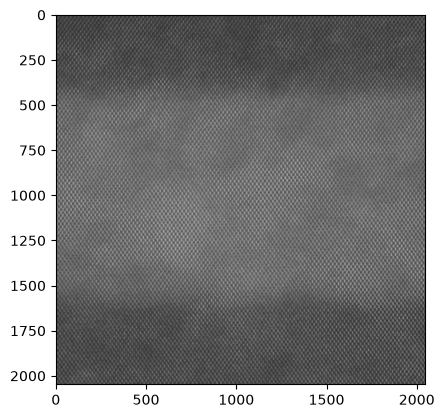

In [4]:
# Read file
file_path = 'Ge.tif'

# Load and plot image
image = np.array(Image.open(f'{file_path}'))

plt.imshow(image, cmap = 'gray')
plt.show()

# Denoise

(2048, 2048)
(2048, 2048)
Batch 1/1
1 image was decoded in approximately 2.8079 seconds
(2048, 2048)
(2048, 2048)


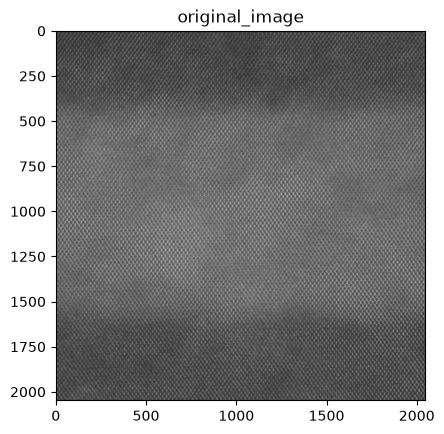

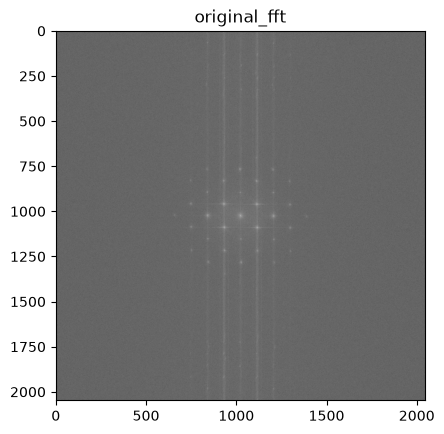

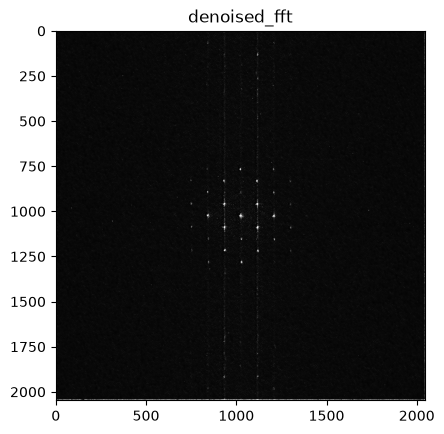

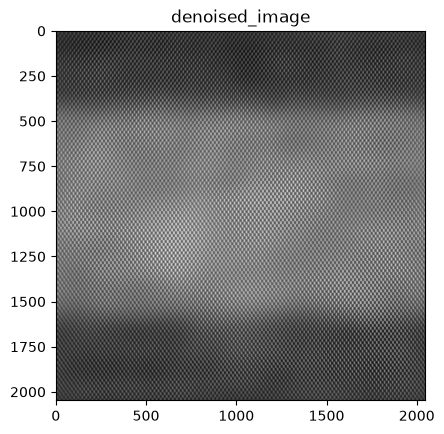

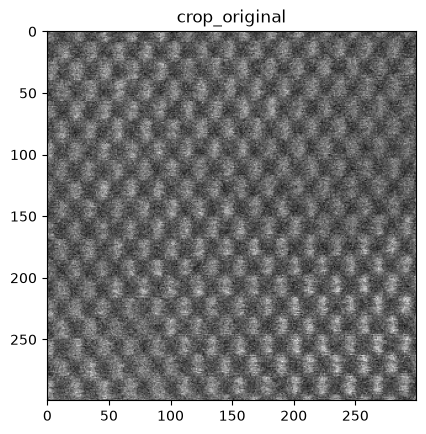

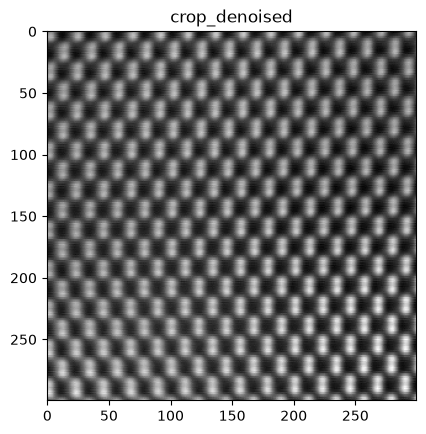

In [5]:
dic_process = fft_denoising(image, dl_model, all_process = True)
process = list(dic_process.values())

# Plot results
for title, result in dic_process.items():
    plt.imshow(result, cmap='gray')
    plt.title(title)
    plt.show()

# Plot croped region
plt.imshow(process[0][700:1000, 700:1000], cmap='gray')
plt.title('crop_original')
plt.show()

plt.imshow(process[-1][700:1000, 700:1000], cmap='gray')
plt.title('crop_denoised')
plt.show()

# Denoise: experimental benchmark dataset

In [8]:
import tifffile

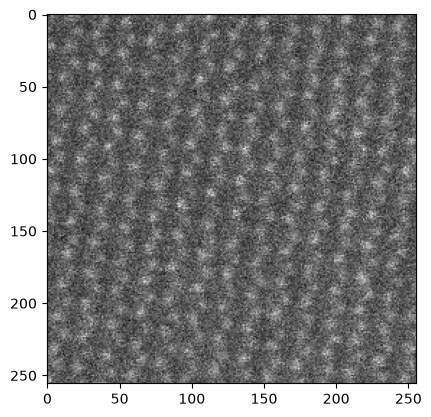

In [6]:
# Read file
file_path = 'DATASET_WEI_ATOM_WS2_CONTRAST\\Image_ID_0123.tif'

# Load and plot image
image = np.array(Image.open(f'{file_path}'))

plt.imshow(image, cmap = 'gray')
plt.show()

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0974 seconds
(256, 256)
(256, 256)


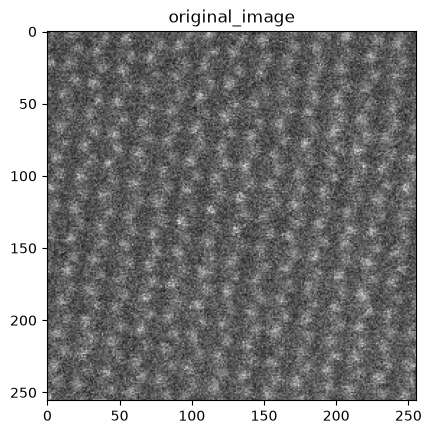

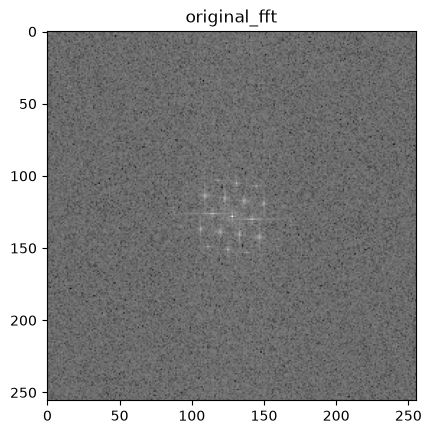

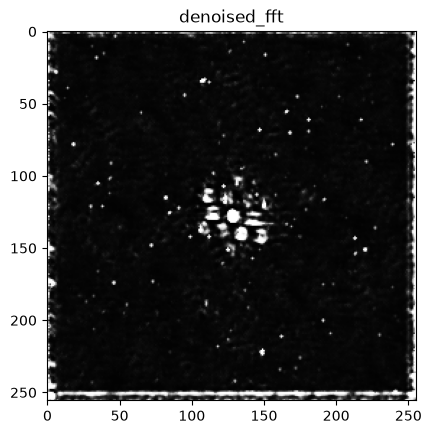

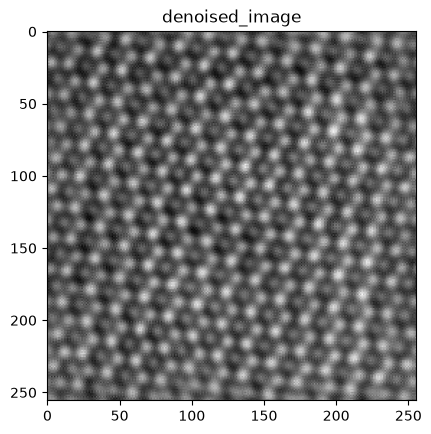

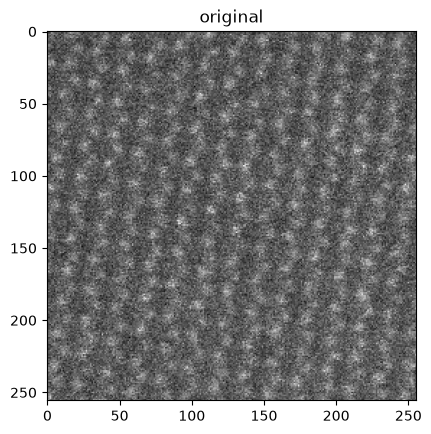

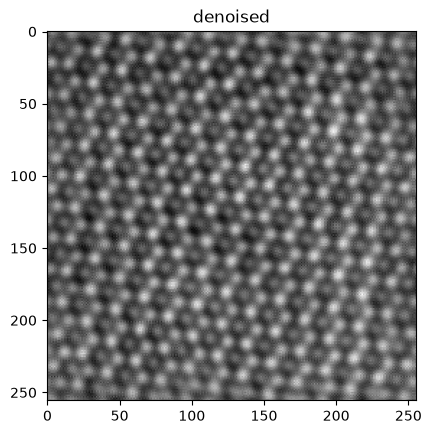

In [7]:
dic_process = fft_denoising(image, dl_model, all_process = True)
process = list(dic_process.values())

# Plot results
for title, result in dic_process.items():
    plt.imshow(result, cmap='gray')
    plt.title(title)
    plt.show()

# Plot
plt.imshow(process[0], cmap='gray')
plt.title('original')
plt.show()

plt.imshow(process[-1], cmap='gray')
plt.title('denoised')
plt.show()

In [9]:
keys = ["0123", "0124", "0125", "0126", "0127", "0128", "0129", "0130"]

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0671 seconds
(256, 256)
(256, 256)


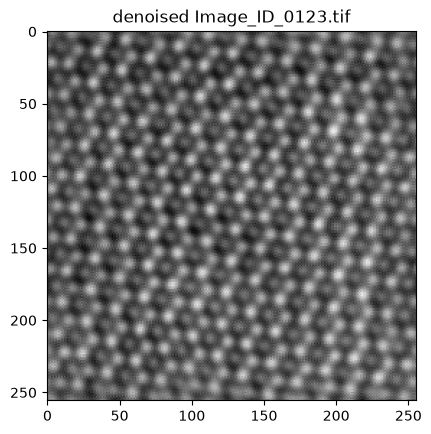

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0694 seconds
(256, 256)
(256, 256)


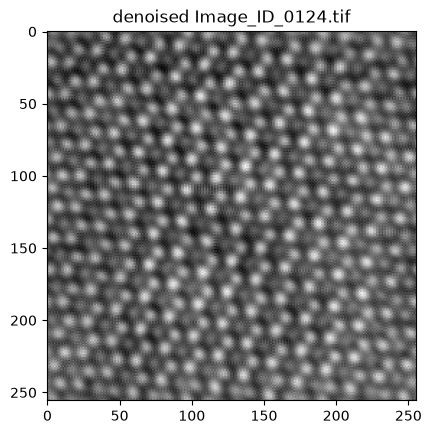

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0557 seconds
(256, 256)
(256, 256)


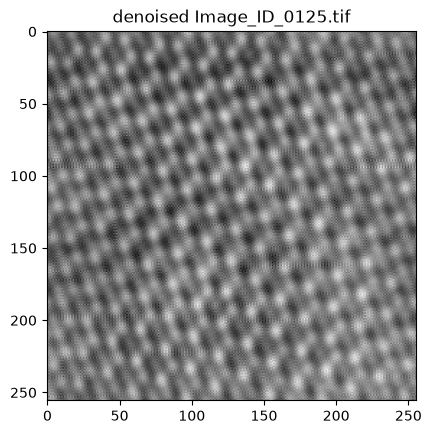

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0538 seconds
(256, 256)
(256, 256)


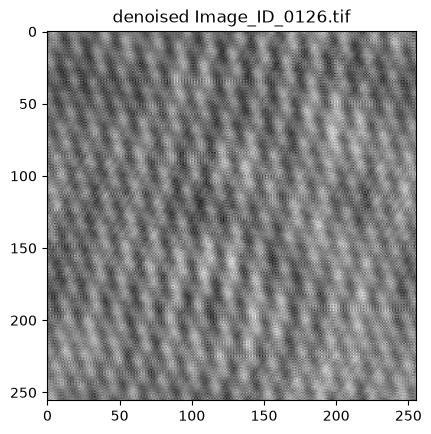

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.064 seconds
(256, 256)
(256, 256)


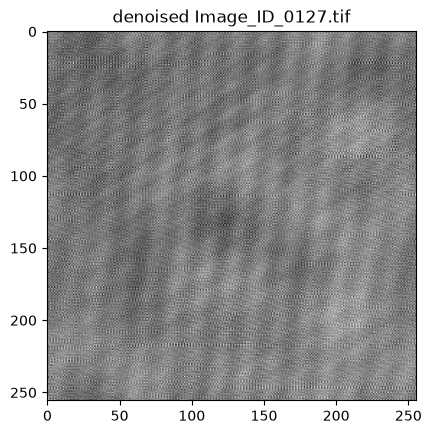

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0538 seconds
(256, 256)
(256, 256)


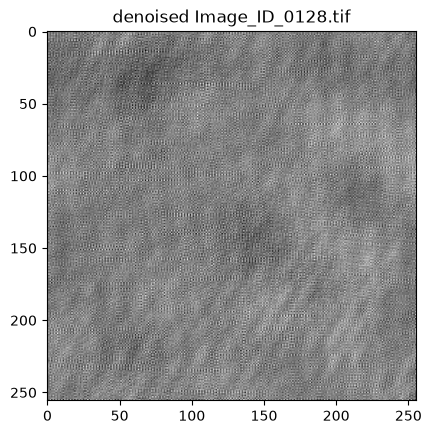

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0538 seconds
(256, 256)
(256, 256)


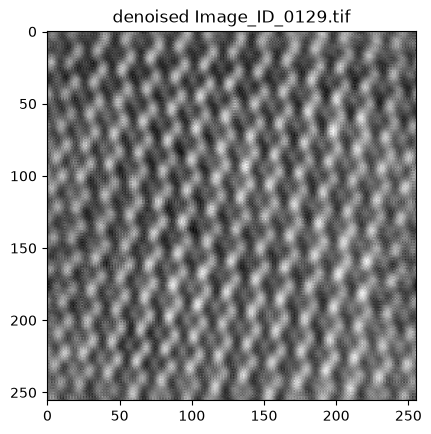

(256, 256)
(256, 256)
Batch 1/1
1 image was decoded in approximately 0.0604 seconds
(256, 256)
(256, 256)


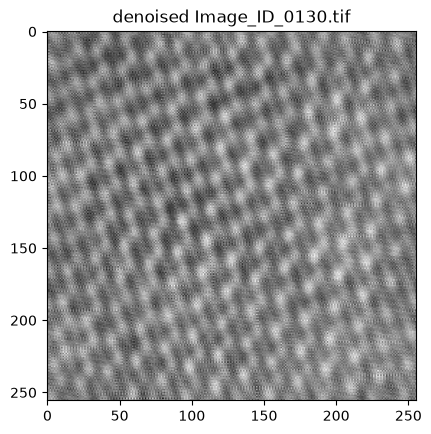

In [11]:
for key in keys:
    # Read file
    file_path = 'DATASET_WEI_ATOM_WS2_CONTRAST\\Image_ID_' + key + '.tif'
    # Load and plot image
    image = np.array(Image.open(f'{file_path}'))
    dic_process = fft_denoising(image, dl_model, all_process = True)
    process = list(dic_process.values())
    plt.imshow(process[-1], cmap='gray')
    plt.title('denoised Image_ID_' + key + '.tif')
    plt.show()    
    img = np.asarray(process[-1]).squeeze()
    # normalize to 0–255
    img = img - img.min()
    img = img / (img.max() + 1e-12)
    img = (img * 255).astype(np.uint8)
    tifffile.imwrite(
        'DATASET_WEI_ATOM_WS2_CONTRAST\\denoised_pinto\\Image_ID_' + key + '_denoised_pinto.tif',
        img,
        imagej=True)